In [15]:
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd

DATA_FILES = {
    "QUT-DV25": Path("ablate_qut_hunt/qut_hunt_rarity.tsv"),
    "OSPTrack": Path("ablate_osp_hunt/osp_hunt_rarity.tsv"),
}

REQUIRED_COLUMNS = {
    "rarity_etypes",
    "rarity_lambda",
    "rarity_idf_cap",
    "base_auroc",
    "rarity_auroc",
}

NUMERIC_COLUMNS = [
    "rarity_lambda",
    "rarity_idf_cap",
    "base_auroc",
    "base_auprc",
    "rarity_auroc",
    "rarity_auprc",
    "returncode",
]


def candidate_roots() -> list[Path]:
    cwd = Path.cwd().resolve()
    roots = [cwd, cwd / "ablation"]
    roots.extend(parent / "ablation" for parent in cwd.parents)
    return list(dict.fromkeys(roots))


def resolve_data_path(relative_path: Path) -> Path:
    checked = []
    for root in candidate_roots():
        path = root / relative_path
        checked.append(path)
        if path.exists():
            return path

    checked_text = "\n".join(f"  - {path}" for path in checked)
    raise FileNotFoundError(f"Could not find {relative_path}. Checked:\n{checked_text}")


def load_rarity_tsv(relative_path: Path) -> pd.DataFrame:
    path = resolve_data_path(relative_path)
    df = pd.read_csv(
        path,
        sep="\t",
        keep_default_na=False,
        na_values=["nan", "NaN", "NA"],
        dtype={"rarity_etypes": "string"},
    )
    df.attrs["source_path"] = path
    return df


raw_datasets = {name: load_rarity_tsv(path) for name, path in DATA_FILES.items()}
raw_datasets.keys()

dict_keys(['QUT-DV25', 'OSPTrack'])

In [16]:
SCOPE_ALIASES = {
    "": "ALL",
    "ALL": "ALL",
    "NET_ONLY": "NET_ONLY",
    "PROC|DNS_QUERY|NET,PROC|RESOLVE|NET,PROC|CONNECT|NET": "NET_ONLY",
    "NET_AND_CMD": "NET_AND_CMD",
    "PROC|DNS_QUERY|NET,PROC|RESOLVE|NET,PROC|CONNECT|NET,PROC|EXEC|CMD": "NET_AND_CMD",
    "CONNECT_ONLY": "CONNECT_ONLY",
    "PROC|CONNECT|NET": "CONNECT_ONLY",
}


def normalize_scope_label(value: object) -> str:
    if pd.isna(value):
        return "ALL"

    text = str(value).strip()
    normalized = ",".join(part.strip().upper() for part in text.split(",") if part.strip())
    return SCOPE_ALIASES.get(normalized, text)


def prepare_rarity_frame(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    missing = REQUIRED_COLUMNS.difference(df.columns)
    if missing:
        missing_text = ", ".join(sorted(missing))
        raise KeyError(f"{dataset_name} is missing required columns: {missing_text}")

    prepared = df.copy()
    prepared["scope"] = prepared["rarity_etypes"].map(normalize_scope_label)

    for column in NUMERIC_COLUMNS:
        if column in prepared.columns:
            prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    if "returncode" in prepared.columns:
        failed_runs = prepared[prepared["returncode"].fillna(0) != 0]
        if not failed_runs.empty:
            print(f"{dataset_name}: dropping {len(failed_runs)} failed run(s).")
            prepared = prepared.drop(failed_runs.index)

    metric_columns = ["rarity_lambda", "rarity_idf_cap", "base_auroc", "rarity_auroc"]
    invalid_rows = prepared[metric_columns].isna().any(axis=1)
    if invalid_rows.any():
        print(f"{dataset_name}: dropping {int(invalid_rows.sum())} row(s) with missing metrics.")
        prepared = prepared.loc[~invalid_rows]

    return prepared.sort_values(["scope", "rarity_idf_cap", "rarity_lambda"]).reset_index(drop=True)


prepared_datasets = {
    name: prepare_rarity_frame(df, name)
    for name, df in raw_datasets.items()
}

summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "source": df.attrs.get("source_path"),
            "rows": len(frame),
            "scopes": ", ".join(frame["scope"].drop_duplicates()),
            "idf_caps": list(frame["rarity_idf_cap"].drop_duplicates()),
            "lambdas": list(frame["rarity_lambda"].drop_duplicates()),
        }
        for name, frame in prepared_datasets.items()
        for df in [raw_datasets[name]]
    ]
)

summary

,dataset,source,rows,scopes,idf_caps,lambdas
0,QUT-DV25,/Users/zhuoran/Projects/DDGRL/ablation/ablate_...,27,"ALL, NET_AND_CMD, NET_ONLY","[0.0, 2.0, 5.0]","[0.1, 0.3, 0.5]"
1,OSPTrack,/Users/zhuoran/Projects/DDGRL/ablation/ablate_...,27,"ALL, CONNECT_ONLY, NET_ONLY","[1.0, 2.0, 3.0]","[0.05, 0.1, 0.3]"


In [17]:
def ordered_scopes(frame: pd.DataFrame, preferred_order: Iterable[str] | None = None) -> list[str]:
    available = list(frame["scope"].drop_duplicates())
    if preferred_order is None:
        return available

    ordered = [scope for scope in preferred_order if scope in available]
    ordered.extend(scope for scope in available if scope not in ordered)
    return ordered


SCOPE_COLORS = {
    "ALL": "tab:blue",
    "NET_ONLY": "red",
    "NET_AND_CMD": "green",
    "CONNECT_ONLY": "green",
}


def plot_metric_sensitivity(
    frame: pd.DataFrame,
    dataset_name: str,
    *,
    metric: str = "auroc",
    scope_order: Iterable[str] | None = None,
    idf_caps: Iterable[float] | None = None,
    title_suffix: str = "",
):
    if frame.empty:
        raise ValueError(f"{dataset_name} has no valid rows to plot.")

    base_column = f"base_{metric}"
    rarity_column = f"rarity_{metric}"
    for column in [base_column, rarity_column]:
        if column not in frame.columns:
            raise KeyError(f"{dataset_name} is missing metric column: {column}")

    caps = sorted(frame["rarity_idf_cap"].dropna().unique()) if idf_caps is None else list(idf_caps)
    if not caps:
        raise ValueError(f"{dataset_name} has no idf caps to plot.")

    scopes = ordered_scopes(frame, scope_order)
    fig, axes = plt.subplots(1, len(caps), figsize=(5 * len(caps), 4.6), sharey=True, squeeze=False)
    axes = axes[0]

    baseline_values = frame[base_column].dropna().unique()
    if len(baseline_values) == 0:
        raise ValueError(f"{dataset_name} has no valid {base_column} values.")
    baseline = float(baseline_values[0])

    for ax, cap in zip(axes, caps):
        subset = frame[frame["rarity_idf_cap"] == cap]
        ax.axhline(baseline, linestyle="--", linewidth=1.5, label=f"Base ({baseline:.3f})")

        plotted = False
        for scope in scopes:
            current = subset[subset["scope"] == scope]
            if current.empty:
                continue

            current = (
                current.groupby("rarity_lambda", as_index=False)[rarity_column]
                .mean()
                .sort_values("rarity_lambda")
            )
            ax.plot(
                current["rarity_lambda"],
                current[rarity_column],
                marker="o",
                linewidth=2,
                label=scope,
                color=SCOPE_COLORS.get(scope),
            )
            plotted = True

        if not plotted:
            ax.text(0.5, 0.5, "No rows", ha="center", va="center", transform=ax.transAxes)

        lambdas = sorted(subset["rarity_lambda"].dropna().unique())
        if lambdas:
            ax.set_xticks(lambdas)
        ax.set_title(f"idf_cap = {cap:g}")
        ax.set_xlabel("rarity_lambda")
        ax.set_ylabel(metric.upper())
        ax.grid(True, alpha=0.3)

    handles_by_label = {}
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        handles_by_label.update(dict(zip(labels, handles)))

    title = f"{dataset_name}: {metric.upper()} sensitivity to rarity scope and strength{title_suffix}"
    fig.suptitle(title, y=0.98)

    if handles_by_label:
        fig.legend(
            handles_by_label.values(),
            handles_by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 0.91),
            ncol=min(4, len(handles_by_label)),
            frameon=False,
        )

    fig.subplots_adjust(top=0.76, wspace=0.18)
    return fig, axes

(<Figure size 1500x460 with 3 Axes>,
 array([<Axes: title={'center': 'idf_cap = 1'}, xlabel='rarity_lambda', ylabel='AUROC'>,
        <Axes: title={'center': 'idf_cap = 2'}, xlabel='rarity_lambda', ylabel='AUROC'>,
        <Axes: title={'center': 'idf_cap = 3'}, xlabel='rarity_lambda', ylabel='AUROC'>],
       dtype=object))

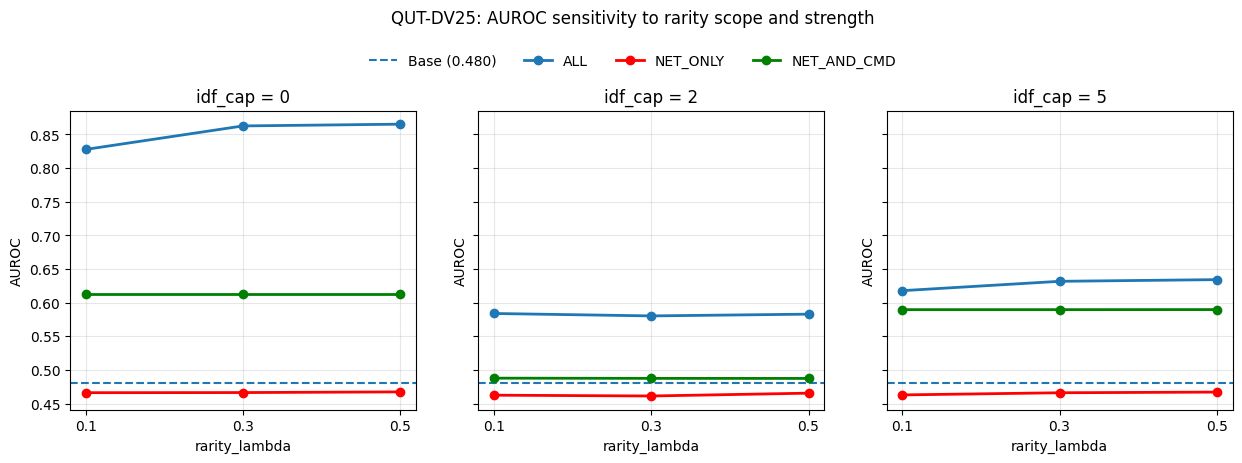

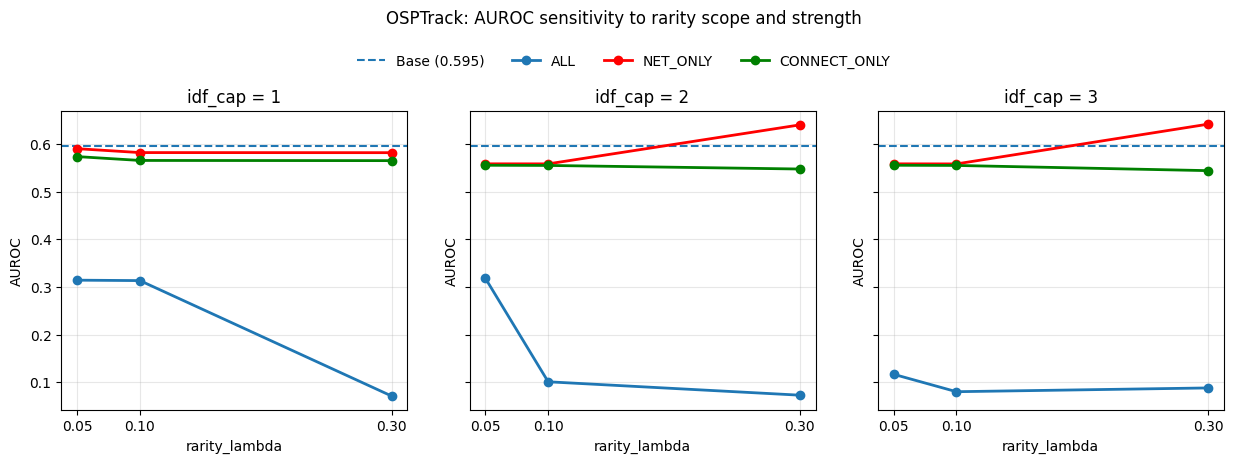

In [18]:
plot_metric_sensitivity(
    prepared_datasets["QUT-DV25"],
    "QUT-DV25",
    metric="auroc",
    scope_order=["ALL", "NET_ONLY", "NET_AND_CMD"],
)

plot_metric_sensitivity(
    prepared_datasets["OSPTrack"],
    "OSPTrack",
    metric="auroc",
    scope_order=["ALL", "NET_ONLY", "CONNECT_ONLY"],
)

(<Figure size 1500x460 with 3 Axes>,
 array([<Axes: title={'center': 'idf_cap = 1'}, xlabel='rarity_lambda', ylabel='AUPRC'>,
        <Axes: title={'center': 'idf_cap = 2'}, xlabel='rarity_lambda', ylabel='AUPRC'>,
        <Axes: title={'center': 'idf_cap = 3'}, xlabel='rarity_lambda', ylabel='AUPRC'>],
       dtype=object))

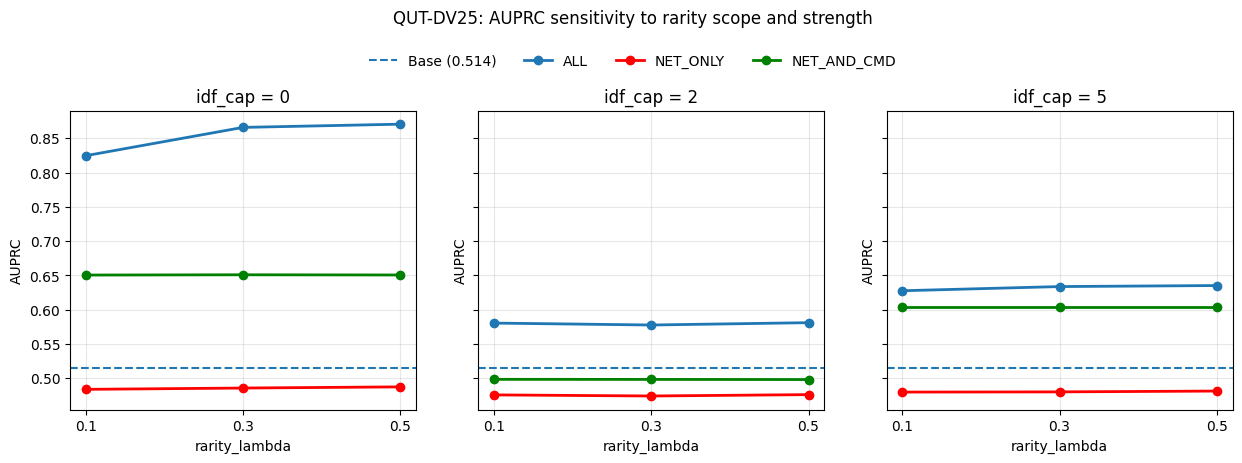

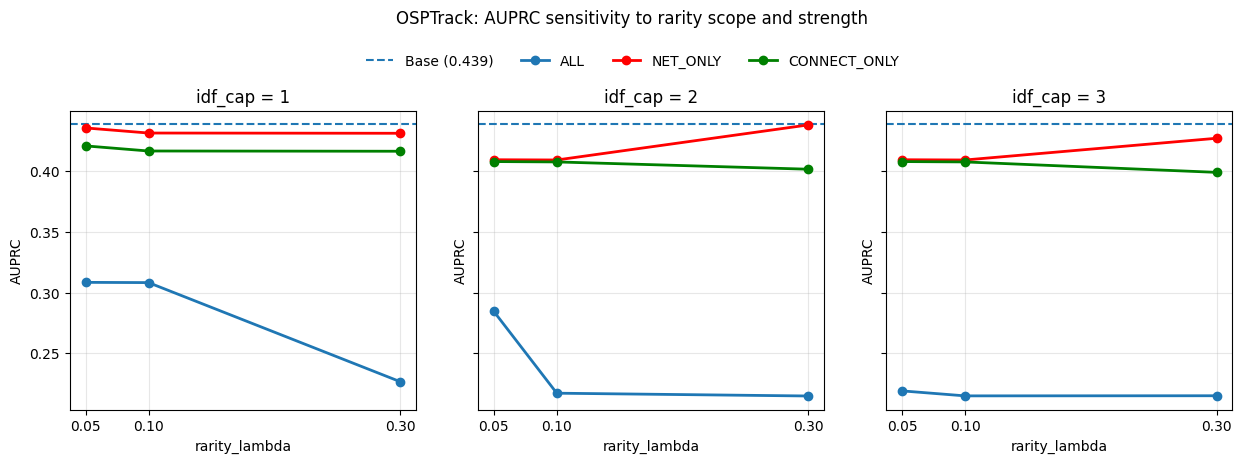

In [19]:
plot_metric_sensitivity(
    prepared_datasets["QUT-DV25"],
    "QUT-DV25",
    metric="auprc",
    scope_order=["ALL", "NET_ONLY", "NET_AND_CMD"],
)

plot_metric_sensitivity(
    prepared_datasets["OSPTrack"],
    "OSPTrack",
    metric="auprc",
    scope_order=["ALL", "NET_ONLY", "CONNECT_ONLY"],
)

In [6]:
best_rows = []
for dataset_name, frame in prepared_datasets.items():
    for metric in ["auroc", "auprc"]:
        base_column = f"base_{metric}"
        rarity_column = f"rarity_{metric}"
        if base_column not in frame.columns or rarity_column not in frame.columns:
            continue

        valid = frame.dropna(subset=[base_column, rarity_column]).copy()
        if valid.empty:
            continue

        best = valid.loc[valid[rarity_column].idxmax()]
        base_value = float(best[base_column])
        rarity_value = float(best[rarity_column])
        best_rows.append(
            {
                "dataset": dataset_name,
                "metric": metric.upper(),
                "scope": best["scope"],
                "rarity_lambda": best["rarity_lambda"],
                "rarity_idf_cap": best["rarity_idf_cap"],
                "base": base_value,
                "best_rarity": rarity_value,
                "delta": rarity_value - base_value,
            }
        )

best_summary = pd.DataFrame(best_rows)
best_summary

,dataset,metric,scope,rarity_lambda,rarity_idf_cap,base,best_rarity,delta
0,QUT-DV25,AUROC,ALL,0.5,0.0,0.4800,0.8653,0.3853
1,QUT-DV25,AUPRC,ALL,0.5,0.0,0.5145,0.8707,0.3562
2,OSPTrack,AUROC,NET_ONLY,0.3,3.0,0.5954,0.6413,0.0459
3,OSPTrack,AUPRC,NET_ONLY,0.3,2.0,0.4387,0.4381,-0.0006
